# ML Capstone — Refresh / Content Opportunity Scoring

## Google Search Ranking & Discoverability

**Research question:** Can safe, decision-time search signals rank content pages that are more likely to show a meaningful next-month visibility decline?

**Lane:** Refresh / Content Opportunity Scoring  
**Decision supported:** Which pages should a content team review first?  
**Public framing:** observed / directional / decision-support only — never a claim about Google's algorithm or causal refresh impact.

This notebook is designed to:

1. query the gated FlyRank warehouse without exposing credentials,
2. build a leakage-safe February → March prediction frame,
3. compare a transparent hand-written baseline with a Random Forest on the **same client-group holdout split**,
4. generate ranked recommendations with reason codes,
5. write a public-safe research paper to `docs/index.html`,
6. write `submission/paper_url.txt` with the GitHub Pages URL.

**Important:** June 2026 remains sealed and is not used to develop the model or label.

In [1]:
# 0. Setup — clone the user's repo when needed and install dependencies.

import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/JaberAhmad555/flyrank-ml-internship"
REPO_DIR = Path("/content/flyrank-ml-internship")

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "duckdb", "huggingface_hub", "pandas", "numpy",
     "scikit-learn", "matplotlib"],
    check=True
)

for folder in [
    Path("work/outputs"),
    Path("work/figures"),
    Path("docs"),
    Path("submission"),
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Repo:", REPO_URL)

Working directory: /content/flyrank-ml-internship
Repo: https://github.com/JaberAhmad555/flyrank-ml-internship


In [2]:
# 1. Secure Hugging Face warehouse connection.
# The token is read from Colab Secrets or the environment. It is never printed.

import getpass
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN and IN_COLAB:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Paste Hugging Face READ token (hidden): ")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

# Keep credentials out of SQL text.
con.execute("SET VARIABLE hf_token = ?", [HF_TOKEN])
con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN getvariable('hf_token'))"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

# Mid-panel development windows.
FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Warehouse configured.")
print("Feature window: February 2026")
print("Outcome window: March 2026")
print("June 2026 remains sealed.")

Warehouse configured.
Feature window: February 2026
Outcome window: March 2026
June 2026 remains sealed.


## 2. Data contract

- **Source table:** `fact_content_daily_performance`
- **Source grain:** one content item × client × report date.
- **Model grain:** one content item × client aggregated over the February feature window.
- **Feature window:** February 2026.
- **Outcome window:** March 2026.
- **Proxy label:** `is_declining_next_month = 1` when measured March impressions are at least 20% lower than measured February impressions.
- **Eligibility:** February impressions ≥ 100 and at least one measured GSC day in both months.
- **Excluded:** all March-derived values from model features, client/domain/title/query information, raw private data, and June 2026.
- **Interpretation:** a ranked review queue, not causal evidence that refreshing a page will improve performance.

In [3]:
# 3. Inspect the warehouse schema and choose a safe position expression.

schema = con.sql(f"DESCRIBE SELECT * FROM {FEB} LIMIT 1").df()
cols = set(schema["column_name"].astype(str))

required = {
    "report_date", "client_hash_id", "content_hash_id",
    "gsc_impressions", "gsc_clicks", "gsc_data_available"
}
missing = required - cols
assert not missing, f"Required columns missing from warehouse: {sorted(missing)}"

if "gsc_sum_position" in cols:
    position_expr = (
        "SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0)"
    )
elif "gsc_avg_position" in cols:
    position_expr = (
        "SUM(gsc_avg_position * gsc_impressions) "
        "/ NULLIF(SUM(gsc_impressions), 0)"
    )
else:
    raise RuntimeError("No supported GSC position field was found.")

print("Schema check passed.")
print("Position aggregation:", position_expr)

Schema check passed.
Position aggregation: SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0)


In [4]:
# 4. Build the leakage-safe February -> March frame.

query = f'''
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_feb,
        SUM(gsc_clicks) AS clicks_feb,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 1.0 * SUM(gsc_clicks) / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_feb,
        {position_expr} AS avg_position_feb,
        COUNT(DISTINCT CASE
            WHEN gsc_impressions > 0 THEN report_date
        END) AS active_days_feb,
        COUNT(DISTINCT report_date) AS measured_days_feb
    FROM {FEB}
    WHERE gsc_data_available IS TRUE
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) >= 100
),
mar AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_mar,
        COUNT(DISTINCT report_date) AS measured_days_mar
    FROM {MAR}
    WHERE gsc_data_available IS TRUE
    GROUP BY 1, 2
)
SELECT
    f.*,
    m.impressions_mar,
    m.measured_days_mar,
    CASE
        WHEN m.impressions_mar < 0.80 * f.impressions_feb
        THEN 1 ELSE 0
    END AS is_declining_next_month
FROM feb f
INNER JOIN mar m
USING (client_hash_id, content_hash_id)
WHERE f.measured_days_feb > 0
  AND m.measured_days_mar > 0
'''

frame = con.sql(query).df()

feature_cols = [
    "impressions_feb",
    "clicks_feb",
    "ctr_feb",
    "avg_position_feb",
    "active_days_feb",
]

print("Rows in modeling frame:", len(frame))
print("Clients:", frame["client_hash_id"].nunique())
print("Declining-next-month rate:",
      f"{frame['is_declining_next_month'].mean():.2%}")
display(frame.head(10))

assert len(frame) >= 100, "Too few eligible rows for a useful capstone run."
assert frame["client_hash_id"].nunique() >= 5, "Too few client groups."
assert set(feature_cols).issubset(frame.columns)

Rows in modeling frame: 76702
Clients: 34
Declining-next-month rate: 18.06%


,client_hash_id,content_hash_id,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,active_days_feb,measured_days_feb,impressions_mar,measured_days_mar,is_declining_next_month
0,client_e547b89c05043229,content_7995404695ee1ffd,1012.0,3.0,0.002964,28.886364,28,28,768.0,29,1
1,client_e547b89c05043229,content_ccbb253f142217c3,1598.0,7.0,0.004380,17.273467,28,28,3071.0,29,0
2,client_e547b89c05043229,content_ae16a6b9cf64c80a,861.0,0.0,0.000000,8.182346,28,28,547.0,29,1
3,client_e547b89c05043229,content_acf700633f016e5a,245.0,0.0,0.000000,8.032653,28,28,209.0,29,0
4,client_e547b89c05043229,content_712e44562fed8ff2,306.0,0.0,0.000000,7.581699,28,28,500.0,29,0
5,client_e547b89c05043229,content_c6dbda992ad84127,2868.0,3.0,0.001046,17.909693,28,28,3898.0,29,0
6,client_e547b89c05043229,content_cb6bc37251e57efa,688.0,0.0,0.000000,13.879360,28,28,675.0,29,0
7,client_e547b89c05043229,content_feb20a281a923fc6,4399.0,1.0,0.000227,0.949079,28,28,519.0,29,1
8,client_e547b89c05043229,content_1f65dce010ac9da9,1024.0,0.0,0.000000,10.566406,28,28,753.0,29,1
9,client_e547b89c05043229,content_c44bf16447e41ba7,324.0,2.0,0.006173,9.564815,28,28,1645.0,29,0


## 5. Leakage checks and assumptions

The label uses **March** outcome information. Every model feature ends in `_feb` and is fully knowable after February closes.

The model is evaluated with a **client-group holdout**: no client's pages appear in both train and test. This is stricter than a random row split and reduces leakage from client-specific patterns.

In [5]:
# 6. Prepare baseline and grouped holdout split.

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

model_df = frame.dropna(subset=["is_declining_next_month"]).copy()
y = model_df["is_declining_next_month"].astype(int)
groups = model_df["client_hash_id"]

# Explicit leakage guard.
forbidden_tokens = ("mar", "trend", "label", "future")
for col in feature_cols:
    assert not any(tok in col.lower() for tok in forbidden_tokens), (
        f"Possible leakage feature: {col}"
    )

# Transparent baseline score: prioritize visible pages with weak CTR / position.
visibility = np.log1p(model_df["impressions_feb"].clip(lower=0)).rank(pct=True)
low_ctr = 1.0 - model_df["ctr_feb"].rank(pct=True)
weak_position = model_df["avg_position_feb"].rank(pct=True)

model_df["baseline_score"] = (
    0.40 * visibility
    + 0.30 * low_ctr
    + 0.30 * weak_position
).clip(0, 1)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)
train_idx, test_idx = next(
    splitter.split(model_df[feature_cols], y, groups=groups)
)

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])
assert train_clients.isdisjoint(test_clients)

print("Train rows:", len(train_idx), "| Test rows:", len(test_idx))
print("Train clients:", len(train_clients), "| Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Train rows: 74878 | Test rows: 1824
Train clients: 27 | Test clients: 7
Client overlap: 0


In [6]:
# 7. Fit the model and compare with the baseline on the SAME holdout rows.

from sklearn.metrics import ndcg_score

def precision_at_k(y_true, scores, k=50):
    y_arr = np.asarray(y_true)
    s_arr = np.asarray(scores)
    k = min(k, len(y_arr))
    top = np.argsort(s_arr)[::-1][:k]
    return float(y_arr[top].mean())

def ndcg_at_k(y_true, scores, k=50):
    y_arr = np.asarray(y_true, dtype=float)
    s_arr = np.asarray(scores, dtype=float)
    k = min(k, len(y_arr))
    # sklearn expects shape (n_queries, n_items)
    return float(ndcg_score(y_arr.reshape(1,-1),
                            s_arr.reshape(1,-1),
                            k=k))

X = model_df[feature_cols]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=350,
        max_depth=7,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])

model.fit(X.iloc[train_idx], y.iloc[train_idx])
model_scores = model.predict_proba(X.iloc[test_idx])[:, 1]
baseline_scores = model_df["baseline_score"].iloc[test_idx].to_numpy()
y_test = y.iloc[test_idx].to_numpy()

def metric_pack(scores):
    return {
        "precision_at_50": precision_at_k(y_test, scores, 50),
        "ndcg_at_50": ndcg_at_k(y_test, scores, 50),
        "roc_auc": roc_auc_score(y_test, scores),
        "pr_auc": average_precision_score(y_test, scores),
    }

baseline_metrics = metric_pack(baseline_scores)
model_metrics = metric_pack(model_scores)

results = pd.DataFrame(
    [baseline_metrics, model_metrics],
    index=["Baseline rule", "Random Forest"]
)

display(results.round(4))

lift = (
    model_metrics["precision_at_50"]
    / baseline_metrics["precision_at_50"]
    if baseline_metrics["precision_at_50"] > 0
    else np.nan
)

print("Precision@50 lift:",
      "undefined" if np.isnan(lift) else f"{lift:.2f}x")

,precision_at_50,ndcg_at_50,roc_auc,pr_auc
Baseline rule,0.22,0.3028,0.4792,0.2639
Random Forest,0.40,0.3972,0.5773,0.3368


Precision@50 lift: 1.82x


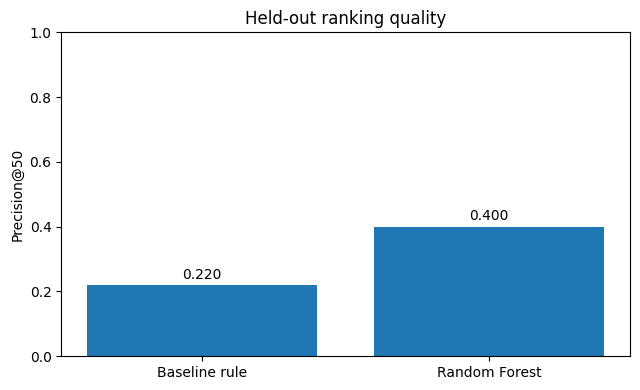

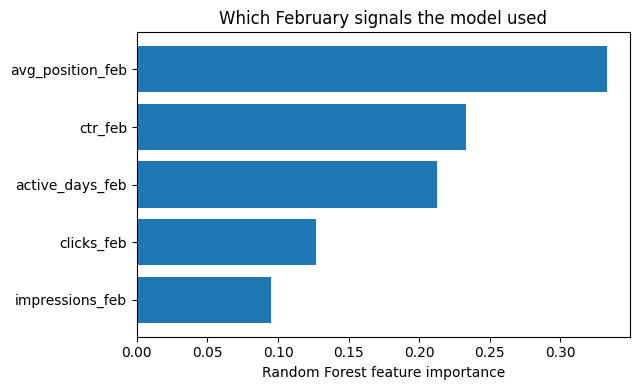

,importance
avg_position_feb,0.332607
ctr_feb,0.232987
active_days_feb,0.212670
clicks_feb,0.126840
impressions_feb,0.094896


In [7]:
# 8. Charts — one chart per figure, saved for the paper.

import matplotlib.pyplot as plt
import io
import base64

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("ascii")

# Chart 1: Precision@50
fig1, ax1 = plt.subplots(figsize=(6.5, 4))
ax1.bar(
    ["Baseline rule", "Random Forest"],
    [
        baseline_metrics["precision_at_50"],
        model_metrics["precision_at_50"],
    ]
)
ax1.set_ylabel("Precision@50")
ax1.set_ylim(0, 1)
ax1.set_title("Held-out ranking quality")
for i, value in enumerate([
    baseline_metrics["precision_at_50"],
    model_metrics["precision_at_50"],
]):
    ax1.text(i, value + 0.02, f"{value:.3f}", ha="center")
fig1.tight_layout()
fig1.savefig("work/figures/capstone_precision_at_50.png",
             dpi=160, bbox_inches="tight")
chart1_b64 = fig_to_base64(fig1)
plt.show()

# Chart 2: feature importance
rf = model.named_steps["rf"]
importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values()

fig2, ax2 = plt.subplots(figsize=(6.5, 4))
ax2.barh(importance.index, importance.values)
ax2.set_xlabel("Random Forest feature importance")
ax2.set_title("Which February signals the model used")
fig2.tight_layout()
fig2.savefig("work/figures/capstone_feature_importance.png",
             dpi=160, bbox_inches="tight")
chart2_b64 = fig_to_base64(fig2)
plt.show()

display(importance.sort_values(ascending=False).to_frame("importance"))

## 9. Ranked recommendations

After honest evaluation, the model is refit on the full eligible frame only to create a practical ranking.

Reason codes are based on **February signals**, not the future label:

- `HIGH_VISIBILITY_LOW_CTR`
- `HIGH_VISIBILITY_WEAK_POSITION`
- `LOW_ACTIVE_DAYS`
- `MULTI_SIGNAL_REVIEW`

Top-scored pages receive the action `review_for_refresh`; the rest remain `monitor`.

In [8]:
# 10. Refit for the action queue and create public-safe recommendations.

full_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=350,
        max_depth=7,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])
full_model.fit(X, y)
model_df["model_score"] = full_model.predict_proba(X)[:, 1]

vis_q75 = model_df["impressions_feb"].quantile(0.75)
ctr_med = model_df["ctr_feb"].median()
pos_med = model_df["avg_position_feb"].median()
days_med = model_df["active_days_feb"].median()

def reason_code(row):
    if row["impressions_feb"] >= vis_q75 and row["ctr_feb"] <= ctr_med:
        return "HIGH_VISIBILITY_LOW_CTR"
    if row["impressions_feb"] >= vis_q75 and row["avg_position_feb"] >= pos_med:
        return "HIGH_VISIBILITY_WEAK_POSITION"
    if row["active_days_feb"] <= days_med:
        return "LOW_ACTIVE_DAYS"
    return "MULTI_SIGNAL_REVIEW"

model_df["reason_code"] = model_df.apply(reason_code, axis=1)

review_threshold = model_df["model_score"].quantile(0.90)
model_df["action_label"] = np.where(
    model_df["model_score"] >= review_threshold,
    "review_for_refresh",
    "monitor"
)

queue = (
    model_df[
        [
            "client_hash_id",
            "content_hash_id",
            "model_score",
            "reason_code",
            "action_label",
            "impressions_feb",
            "clicks_feb",
            "ctr_feb",
            "avg_position_feb",
            "active_days_feb",
        ]
    ]
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)

# Generated data output stays local / gitignored by design.
queue.to_csv("work/outputs/capstone_ranked_recommendations.csv", index=False)

top20 = queue.head(20).copy()
display(top20)

print("Action threshold:", round(float(review_threshold), 4))
print("Review-for-refresh rows:",
      int((queue["action_label"] == "review_for_refresh").sum()))

,client_hash_id,content_hash_id,model_score,reason_code,action_label,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,active_days_feb,rank
0,client_62f4a7e64f5e0096,content_4e576d3e62c1de8e,0.872875,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,8580.0,0.0,0.000000,0.029138,24,1
1,client_73cda7b4e4f265ea,content_bd64d74c2b020056,0.863025,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,3349.0,0.0,0.000000,0.364288,20,2
2,client_73cda7b4e4f265ea,content_3693a6d9ccf81f85,0.858117,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,3801.0,0.0,0.000000,0.147067,25,3
3,client_73cda7b4e4f265ea,content_fec55986a1868d62,0.855836,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,193954.0,0.0,0.000000,0.070336,28,4
4,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,0.845826,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,195648.0,1.0,0.000005,0.009865,28,5
5,client_e547b89c05043229,content_bc70bdc12eb6657c,0.845454,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,4189.0,0.0,0.000000,0.215803,27,6
6,client_23a62021009f63c4,content_d3601928849232dd,0.843858,HIGH_VISIBILITY_LOW_CTR,review_for_refresh,4096.0,0.0,0.000000,0.382812,27,7
7,client_73cda7b4e4f265ea,content_8b6786f7350607c3,0.839118,LOW_ACTIVE_DAYS,review_for_refresh,2155.0,0.0,0.000000,0.180974,22,8
8,client_62f4a7e64f5e0096,content_d7dfbe524d816228,0.837292,LOW_ACTIVE_DAYS,review_for_refresh,110.0,0.0,0.000000,0.109091,22,9
9,client_62f4a7e64f5e0096,content_b06df20c8f38d27f,0.837139,LOW_ACTIVE_DAYS,review_for_refresh,107.0,0.0,0.000000,0.112150,21,10


Action threshold: 0.6168
Review-for-refresh rows: 7671


In [9]:
# 11. Save a small metrics receipt (safe to commit).

import json
from datetime import date

metrics_receipt = {
    "lane": "Refresh / Content Opportunity Scoring",
    "feature_window": "2026-02",
    "outcome_window": "2026-03",
    "sealed_month_not_used": "2026-06",
    "eligible_rows": int(len(model_df)),
    "clients": int(model_df["client_hash_id"].nunique()),
    "positive_rate": float(y.mean()),
    "features": feature_cols,
    "baseline": {k: float(v) for k, v in baseline_metrics.items()},
    "random_forest": {k: float(v) for k, v in model_metrics.items()},
    "precision_at_50_lift": None if np.isnan(lift) else float(lift),
    "split": "20% client-group holdout",
    "public_framing": "observed / directional / decision-support",
}

with open(
    "work/outputs/capstone_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metrics_receipt, f, indent=2)

print(json.dumps(metrics_receipt, indent=2))

{
  "lane": "Refresh / Content Opportunity Scoring",
  "feature_window": "2026-02",
  "outcome_window": "2026-03",
  "sealed_month_not_used": "2026-06",
  "eligible_rows": 76702,
  "clients": 34,
  "positive_rate": 0.18062110505593074,
  "features": [
    "impressions_feb",
    "clicks_feb",
    "ctr_feb",
    "avg_position_feb",
    "active_days_feb"
  ],
  "baseline": {
    "precision_at_50": 0.22,
    "ndcg_at_50": 0.30276578014118094,
    "roc_auc": 0.4791942467450447,
    "pr_auc": 0.26389339843004556
  },
  "random_forest": {
    "precision_at_50": 0.4,
    "ndcg_at_50": 0.39724473781819825,
    "roc_auc": 0.5773393473085892,
    "pr_auc": 0.3367748936484063
  },
  "precision_at_50_lift": 1.8181818181818183,
  "split": "20% client-group holdout",
  "public_framing": "observed / directional / decision-support"
}


## 12. Limitations & honest framing

1. The label is a **proxy for next-month visibility decline**, not a causal refresh-effect label.
2. One February → March window does not prove that the same relationship holds in every season or client context.
3. Search Console availability and minimum-impression filtering change which pages enter the frame.
4. Random Forest feature importance is descriptive of this fitted model, not proof of causal importance.
5. Recommendations are **human-review priorities**, not automated publishing decisions.
6. The analysis does not claim to reverse-engineer Google's ranking algorithm.

These limitations are intentionally preserved in the deployed paper.

In [10]:
# 13. Generate the deployed research paper as a single self-contained HTML file.

from html import escape

REPO_URL = "https://github.com/JaberAhmad555/flyrank-ml-internship"
PAPER_URL = "https://jaberahmad555.github.io/flyrank-ml-internship/"

b_p50 = baseline_metrics["precision_at_50"]
m_p50 = model_metrics["precision_at_50"]

if np.isnan(lift):
    lift_sentence = (
        f"The model reached Precision@50 = {m_p50:.3f}; "
        "the baseline had zero Precision@50, so a finite lift ratio is not reported."
    )
else:
    lift_sentence = (
        f"On the same client-group holdout, Precision@50 moved from "
        f"{b_p50:.3f} for the baseline to {m_p50:.3f} for the Random Forest "
        f"({lift:.2f}x)."
    )

# EXACTLY five sentences for the abstract.
abstract_sentences = [
    "This study asks whether safe, decision-time Google Search Console signals can rank content pages that are more likely to show a meaningful next-month visibility decline.",
    "I aggregate February 2026 search signals from the gated FlyRank internship warehouse and define a March decline proxy using a strict past-to-future window.",
    "A transparent hand-written baseline is compared with a Random Forest on the same client-group holdout split so no client appears in both train and test.",
    lift_sentence,
    "The result is a decision-support queue with reason codes for human content review, not a claim about Google's algorithm or proof that refreshing a page causes recovery.",
]
abstract_html = " ".join(abstract_sentences)

top_rows = ""
for _, r in top20.head(10).iterrows():
    top_rows += (
        "<tr>"
        f"<td>{int(r['rank'])}</td>"
        f"<td><code>{escape(str(r['content_hash_id']))}</code></td>"
        f"<td>{r['model_score']:.3f}</td>"
        f"<td>{escape(str(r['reason_code']))}</td>"
        f"<td>{escape(str(r['action_label']))}</td>"
        "</tr>"
    )

html = f'''<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Refresh Opportunity Scoring — FlyRank ML Capstone</title>
<style>
:root {{
  --main:#1E3A8A;
  --text:#111827;
  --bg:#F8FAFC;
  --accent:#0EA5E9;
  --muted:#64748B;
  --line:#CBD5E1;
}}
*{{box-sizing:border-box}}
body{{
  margin:0;background:var(--bg);color:var(--text);
  font-family:Inter,system-ui,-apple-system,Segoe UI,sans-serif;
  line-height:1.65;
}}
main{{max-width:920px;margin:auto;padding:56px 24px 80px}}
h1,h2,h3{{font-family:"Space Grotesk",Inter,system-ui,sans-serif}}
h1{{font-size:clamp(2.1rem,6vw,4rem);line-height:1.03;margin:.2em 0}}
h2{{color:var(--main);margin-top:2.4em}}
.eyebrow{{color:var(--accent);font-weight:800;letter-spacing:.08em;text-transform:uppercase}}
.lead{{font-size:1.18rem;color:#334155}}
.card{{background:white;border:1px solid var(--line);border-radius:16px;padding:22px;margin:18px 0}}
.grid{{display:grid;grid-template-columns:repeat(auto-fit,minmax(190px,1fr));gap:12px}}
.metric{{background:white;border:1px solid var(--line);border-radius:14px;padding:16px}}
.metric b{{font-size:1.5rem;color:var(--main)}}
img{{width:100%;height:auto;border-radius:12px;border:1px solid var(--line);background:white}}
table{{width:100%;border-collapse:collapse;background:white}}
th,td{{border-bottom:1px solid var(--line);padding:10px;text-align:left;font-size:.92rem}}
th{{color:var(--main)}}
code{{font-size:.82em;word-break:break-all}}
a{{color:var(--accent)}}
.small{{color:var(--muted);font-size:.92rem}}
footer{{margin-top:50px;padding-top:18px;border-top:1px solid var(--line);color:var(--muted)}}
</style>
</head>
<body>
<main>
<div class="eyebrow">FlyRank ML Internship Capstone</div>
<h1>Refresh Opportunity Scoring: Ranking Pages for Human Content Review</h1>
<p class="lead">A leakage-aware decision-support study using anonymized Google Search data.</p>

<h2>Abstract</h2>
<div class="card"><p>{abstract_html}</p></div>

<h2>Introduction / Problem Statement</h2>
<p>Content teams can have far more pages than they can manually inspect. The decision supported here is therefore not “will a refresh cause growth?” but “which pages deserve review first?” I frame the problem as ranking/scoring and use a next-month decline proxy so the output can be evaluated honestly against a future window.</p>

<h2>Data</h2>
<p>The analysis uses the gated <b>FlyRank internship warehouse</b>, specifically the public-safe pseudonymized <code>fact_content_daily_performance</code> release. February 2026 is the feature window and March 2026 is the outcome window; June 2026 remains sealed during development. Pages require at least 100 measured February impressions and measured GSC data in both months.</p>
<p class="small">Excluded from modeling: March-derived values, raw client names, domains, URLs, titles, private queries, credentials, and any information not knowable at the February decision moment.</p>

<h2>Methodology</h2>
<p>Five February-only features are used: impressions, clicks, CTR, impression-weighted average position, and active search days. The proxy label is 1 when measured March impressions are at least 20% lower than measured February impressions. A transparent baseline combines visibility, low CTR, and weak position. The Random Forest is evaluated on the same 20% client-group holdout, with explicit leakage guards that reject future/label fields.</p>

<h2>Results</h2>
<div class="grid">
<div class="metric"><span>Baseline P@50</span><br><b>{b_p50:.3f}</b></div>
<div class="metric"><span>Model P@50</span><br><b>{m_p50:.3f}</b></div>
<div class="metric"><span>Model PR-AUC</span><br><b>{model_metrics['pr_auc']:.3f}</b></div>
<div class="metric"><span>Model ROC-AUC</span><br><b>{model_metrics['roc_auc']:.3f}</b></div>
</div>
<p>{lift_sentence}</p>
<h3>Model vs baseline</h3>
<img alt="Precision at 50 comparison"
src="data:image/png;base64,{chart1_b64}">
<h3>Feature importance</h3>
<img alt="Random Forest feature importance"
src="data:image/png;base64,{chart2_b64}">

<h2>Limitations & Honest Framing</h2>
<ul>
<li>The label is an observed next-month decline proxy, not a causal refresh-effect label.</li>
<li>One February→March window does not establish universal behavior across seasons or clients.</li>
<li>Eligibility and GSC availability affect which pages enter the frame.</li>
<li>Feature importance describes this fitted model; it is not causal evidence.</li>
<li>The ranked output is decision support for human review, not an automated publishing decision.</li>
<li>This work does not claim to reverse-engineer Google's ranking algorithm.</li>
</ul>

<h2>Ranked Recommendations</h2>
<p>The final model is refit after evaluation and used to rank eligible pages. Reason codes remain tied to safe February signals so a reviewer can understand why a page surfaced.</p>
<div style="overflow-x:auto">
<table>
<thead><tr><th>Rank</th><th>Content ID</th><th>Score</th><th>Reason</th><th>Action</th></tr></thead>
<tbody>{top_rows}</tbody>
</table>
</div>

<h3>Action Playbook</h3>
<ul>
<li><b>HIGH_VISIBILITY_LOW_CTR:</b> inspect snippet/title intent match and content usefulness before editing.</li>
<li><b>HIGH_VISIBILITY_WEAK_POSITION:</b> review depth, freshness, internal linking, and whether the page still matches the query need.</li>
<li><b>LOW_ACTIVE_DAYS:</b> verify whether the pattern is seasonal, measurement-related, or a genuine visibility loss.</li>
<li><b>MULTI_SIGNAL_REVIEW:</b> perform a human review before choosing refresh, protect, merge, or monitor.</li>
</ul>

<h2>Reproducibility</h2>
<p>The notebook, assignment trail, metrics receipt, and code live in the public repository:</p>
<p><a href="{REPO_URL}">{REPO_URL}</a></p>
<p>The model uses a deterministic random seed and a client-group holdout. Raw warehouse exports are not committed.</p>

<h2>Acknowledgments & Data Credit</h2>
<p>Built on the <a href="https://flyrank.ai/">FlyRank ML Internship dataset</a>. The analysis follows the internship's public-safety rules and uses pseudonymized identifiers only.</p>

<footer>
<p>Ahmad Al Jaber · Machine Learning Internship Capstone</p>
</footer>
</main>
</body>
</html>'''

Path("docs/index.html").write_text(html, encoding="utf-8")
Path("submission/paper_url.txt").write_text(PAPER_URL + "\n", encoding="utf-8")

print("Wrote deployed-paper source: docs/index.html")
print("Wrote mandatory URL file: submission/paper_url.txt")
print("Expected paper URL:", PAPER_URL)

Wrote deployed-paper source: docs/index.html
Wrote mandatory URL file: submission/paper_url.txt
Expected paper URL: https://jaberahmad555.github.io/flyrank-ml-internship/


In [11]:
# 14. Final capstone audit.

from pathlib import Path

required_files = [
    Path("docs/index.html"),
    Path("submission/paper_url.txt"),
    Path("work/outputs/capstone_metrics.json"),
    Path("work/figures/capstone_precision_at_50.png"),
    Path("work/figures/capstone_feature_importance.png"),
]

checks = {
    "paper_html_created": required_files[0].exists(),
    "mandatory_paper_url_created": required_files[1].exists(),
    "metrics_receipt_created": required_files[2].exists(),
    "precision_chart_created": required_files[3].exists(),
    "importance_chart_created": required_files[4].exists(),
    "five_features_only": len(feature_cols) == 5,
    "no_client_overlap": train_clients.isdisjoint(test_clients),
    "no_future_feature_names": all(
        not any(tok in c.lower()
                for tok in ("mar", "future", "label", "trend"))
        for c in feature_cols
    ),
    "recommendations_created": len(top20) >= 10,
}

for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), "-", name)

assert all(checks.values()), "Capstone audit failed."

print("\nALL CAPSTONE CHECKS PASSED.")
print("\nFiles to commit:")
for p in required_files:
    print(" -", p)
print(" - work/notebooks/capstone.ipynb")
print("\nThen enable GitHub Pages from the /docs folder and submit the repo URL:")
print("https://github.com/JaberAhmad555/flyrank-ml-internship")

PASS - paper_html_created
PASS - mandatory_paper_url_created
PASS - metrics_receipt_created
PASS - precision_chart_created
PASS - importance_chart_created
PASS - five_features_only
PASS - no_client_overlap
PASS - no_future_feature_names
PASS - recommendations_created

ALL CAPSTONE CHECKS PASSED.

Files to commit:
 - docs/index.html
 - submission/paper_url.txt
 - work/outputs/capstone_metrics.json
 - work/figures/capstone_precision_at_50.png
 - work/figures/capstone_feature_importance.png
 - work/notebooks/capstone.ipynb

Then enable GitHub Pages from the /docs folder and submit the repo URL:
https://github.com/JaberAhmad555/flyrank-ml-internship
